In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [67]:
cities = pd.read_excel('Датасет городов.xlsx').drop('Unnamed: 0', axis=1)
cities

,Город,Регион,Федеральный округ,Население,Наличие аэропорта
0,Абаза,Хакасия,Сибирский,12272,False
1,Абакан,Хакасия,Сибирский,184284,True
2,Абдулино,Оренбургская область,Приволжский,17274,False
3,Абинск,Краснодарский край,Южный,38440,False
4,Агидель,Башкортостан,Приволжский,14219,False
...,...,...,...,...,...
1120,Ярославль,Ярославская область,Центральный,563717,True
1121,Ярцево,Смоленская область,Центральный,40330,False
1122,Ясногорск,Тульская область,Центральный,15269,False
1123,Ясный,Оренбургская область,Приволжский,15471,False


Будем придерживаться следующей стратегии: <br>
Мы хотим диверсифицировать наш анализ по округам, т.е. в каждом округе посмотрим регионы и города - выберем топ в каждой группе (округе). Эти топы и возьмем для дальнейшего анализа.

Проверим, во всех ли федеральных округах есть аэропорт

In [68]:
cities.groupby('Федеральный округ')['Наличие аэропорта'].sum().sort_values()

,Наличие аэропорта
Федеральный округ,
Северо-Кавказский,7
Северо-Западный,8
Южный,8
Уральский,8
Центральный,9
Дальневосточный,10
Сибирский,12
Приволжский,13


Далее выкенем те регионы, в которых нет ни одного аэропорта, т.к. это серьезно влияет на транспортную доступность + далее мы будем рассматривать именно авиаперелеты

In [69]:
a = cities.groupby('Регион')['Наличие аэропорта'].sum().sort_values()
cities1 = cities[~cities['Регион'].isin(a[a == 0].index)]
print(f'до удаления {len(cities)} и после: {len(cities1)}')

до удаления 1125 и после: 878


In [70]:
group = cities1.groupby('Федеральный округ')[['Регион', 'Население']].agg({'Регион': 'count', 'Население':'sum'})
group

,Регион,Население
Федеральный округ,,
Дальневосточный,80,4908776
Приволжский,167,17439797
Северо-Западный,104,9682521
Северо-Кавказский,59,4877311
Сибирский,109,11268723
Уральский,98,8725039
Центральный,168,25103355
Южный,93,9391463


Посмотрим на плотность население по округам

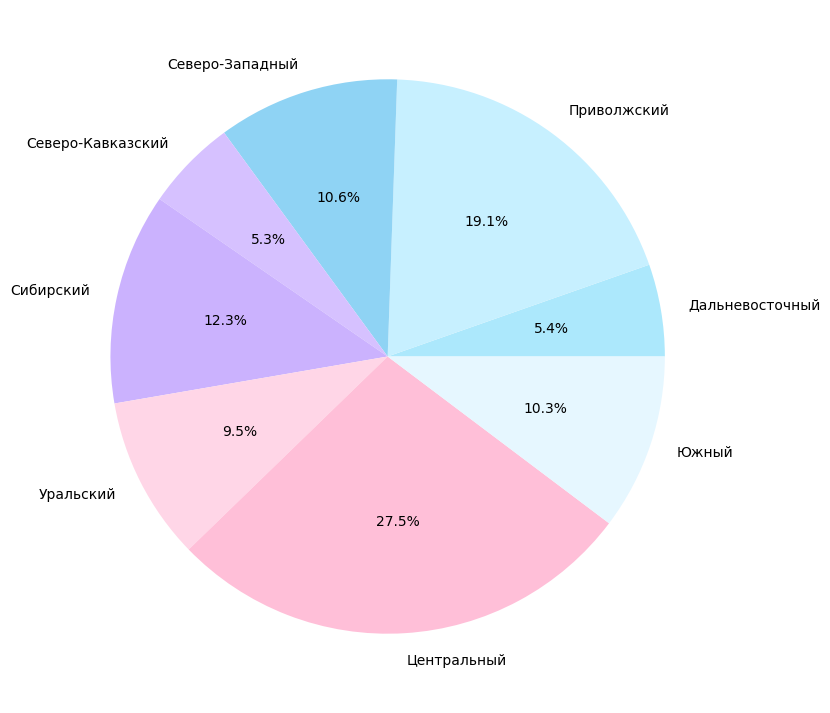

In [71]:
labels = group.index
sizes = group['Население'] / group['Население'].sum()

plt.figure(figsize=(16, 9))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#ace8fc','#c7f0ff','#8fd3f4','#d6c1ff','#cbb2fe','#ffd6e7','#ffbfd8','#e6f7ff'])
plt.show()

Далее мы хотим сохранить все округа, но выкинуть оттуда города с наименьшим населением - там меньше всего экономической активности. Плотность в разных округах тоже разная, поэтому граница отбрасывания тоже должна зависеть напрямую от статистики населения округа

In [72]:
districts = cities['Федеральный округ'].unique()
sl = {}
for elem in districts:
  sl[elem] = cities1[cities1['Федеральный округ'] == elem]['Население'].quantile(0.9)
  print(f'Статистика округа {elem}: 90% данных меньше {cities1[cities1['Федеральный округ'] == elem]['Население'].quantile(0.9)}')

Статистика округа Сибирский: 90% данных меньше 180225.6
Статистика округа Приволжский: 90% данных меньше 196581.20000000016
Статистика округа Южный: 90% данных меньше 212359.9999999999
Статистика округа Северо-Кавказский: 90% данных меньше 146538.80000000005
Статистика округа Уральский: 90% данных меньше 144620.69999999998
Статистика округа Дальневосточный: 90% данных меньше 179120.30000000002
Статистика округа Центральный: 90% данных меньше 180296.8000000001
Статистика округа Северо-Западный: 90% данных меньше 82407.70000000003


Продолжим фильтрацию городов - уберем самые маленькие (нижние 90%), но, если в этом городе есть аэропорт, то мы его осатвим, чтобы не ухудшать транспортную доступность во всем регионе

In [73]:
cities3 = cities1[cities1.apply(lambda x: x['Население'] >= sl[x['Федеральный округ']] or x['Наличие аэропорта'] == True, axis=1)]
len(cities3)

103

In [74]:
len(cities3['Регион'].unique())

63

Осталось 63 региона и 104 города - далее именно их мы и будем рассматривать

In [75]:
cities3.to_excel('Итоговый список городов.xlsx', index=False)

Для следующего этапа нам понадобятся английские названия городов - возьмем его уже из готового json файла с гитхаба https://github.com/arbaev/russia-cities/blob/master/russia-cities.json

In [76]:
df = pd.read_json('russia-cities.json')
cities4 = cities3.merge(df[['name', 'name_en']], left_on='Город', right_on='name', how='left')
cities4

,Город,Регион,Федеральный округ,Население,Наличие аэропорта,name,name_en
0,Абакан,Хакасия,Сибирский,184284,True,Абакан,Abakan
1,Анадырь,Чукотский АО,Дальневосточный,13224,True,Анадырь,Anadyr
2,Анапа,Краснодарский край,Южный,84804,True,Анапа,Anapa
3,Ангарск,Иркутская область,Сибирский,216973,False,Ангарск,Angarsk
4,Архангельск,Архангельская область,Северо-Западный,294914,True,Архангельск,Arkhangelsk
...,...,...,...,...,...,...,...
99,Элиста,Калмыкия,Южный,104082,True,Элиста,Elista
100,Энгельс,Саратовская область,Приволжский,222115,False,Энгельс,Engels
101,Южно-Сахалинск,Сахалинская область,Дальневосточный,181976,True,Южно-Сахалинск,Yuzhno-Sakhalinsk
102,Якутск,Якутия,Дальневосточный,372801,True,Якутск,Yakutsk


In [77]:
df[df['name'] == 'Благовещенск']

,name,name_alt,label,type,typeShort,contentType,id,okato,oktmo,guid,...,isCapital,zip,population,yearFounded,yearCityStatus,name_en,namecase,coords,timezone,region
27,Благовещенск,Благовещенск,blagoveshchensk_bashkortostan,Город,г,city,201500100000,80417000000,80615101001,da7ef573-cdbe-458e-a790-b29ad3a3d140,...,False,453430,35481,1756,1941,Blagoveshchensk,"{'nominative': 'Благовещенск', 'genitive': 'Бл...","{'lat': 55.0499867, 'lon': 55.9553186}","{'tzid': 'Asia/Yekaterinburg', 'abbreviation':...","{'name': 'Башкортостан', 'label': 'bashkortost..."
262,Благовещенск,Благовещенск,blagoveshchensk,Город,г,city,2800000100000,10401000000,10701000001,8f41253d-6e3b-48a9-842a-25ba894bd093,...,True,675014,241437,1856,1858,Blagoveshchensk,"{'nominative': 'Благовещенск', 'genitive': 'Бл...","{'lat': 50.290659, 'lon': 127.527198}","{'tzid': 'Asia/Yakutsk', 'abbreviation': 'YAKT...","{'name': 'Амурская', 'label': 'amurskaya', 'ty..."


In [78]:
cities4[cities4['name_en'].isna() == True]

,Город,Регион,Федеральный округ,Население,Наличие аэропорта,name,name_en
75,Симферополь,Крым,Южный,335009,True,NaN,NaN


In [79]:
cities4[cities4['Город'] == 'Симферополь']

,Город,Регион,Федеральный округ,Население,Наличие аэропорта,name,name_en
75,Симферополь,Крым,Южный,335009,True,NaN,NaN


In [80]:
cities4.loc[76,'name_en'] = 'Simferopol'

In [81]:
cities4[cities4['Город'] == 'Симферополь']

,Город,Регион,Федеральный округ,Население,Наличие аэропорта,name,name_en
75,Симферополь,Крым,Южный,335009,True,NaN,NaN


In [82]:
cities4[cities4['Город'] == 'Благовещенск']

,Город,Регион,Федеральный округ,Население,Наличие аэропорта,name,name_en
9,Благовещенск,Амурская область,Дальневосточный,239932,True,Благовещенск,Blagoveshchensk
10,Благовещенск,Амурская область,Дальневосточный,239932,True,Благовещенск,Blagoveshchensk


In [83]:
cities4 = cities4.drop(10, axis=0)

In [84]:
cities4.to_excel('Итоговый список городов с en.xlsx')